#  Artificial Intelligence and Machine Learning Building Fully Connected Neural Networks for Devnagari Handwritten Digit Classification

In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow import keras
import matplotlib.pyplot as plt
from PIL import Image

# Task 1: Data Preparation

In [2]:
train_dir = "/content/drive/MyDrive/AI and Machine Learning - 6th Sem/Week 4/DevanagariHandwrittenDigitDataset/Train"
test_dir = "/content/drive/MyDrive/AI and Machine Learning - 6th Sem/Week 4/DevanagariHandwrittenDigitDataset/Test"
img_height, img_width = 28,28

In [4]:
# Function to load images and labels using PIL
def load_images_from_folder(folder):
  images = []
  labels = []
  class_names = sorted(os.listdir(folder)) # Sorted class names (digit_0, digit_1, ...)
  class_map = {name: i for i, name in enumerate(class_names)} # Map class names to labels
  for class_name in class_names:
    class_path = os.path.join(folder, class_name)
    label = class_map[class_name]
    for filename in os.listdir(class_path):
      img_path = os.path.join(class_path, filename)
      # Load image using PIL
      img = Image.open(img_path).convert("L") # Convert to grayscale
      img = img.resize((img_width, img_height)) # Resize to (28,28)
      img = np.array(img) / 255.0 # Normalize pixel values to [0,1]
      images.append(img)
      labels.append(label)
  return np.array(images), np.array(labels)

In [5]:
# Load training and testing datasets
x_train, y_train = load_images_from_folder(train_dir)
x_test, y_test = load_images_from_folder(test_dir)
# Reshape images for Keras input
x_train = x_train.reshape(-1, img_height, img_width, 1) # Shape (num_samples, 28, 28, 1)
x_test = x_test.reshape(-1, img_height, img_width, 1)
# One-hot encode labels
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)
# Print dataset shape
print(f"Training set: {x_train.shape}, Labels: {y_train.shape}")
print(f"Testing set: {x_test.shape}, Labels: {y_test.shape}")

Training set: (17014, 28, 28, 1), Labels: (17014, 10)
Testing set: (3000, 28, 28, 1), Labels: (3000, 10)


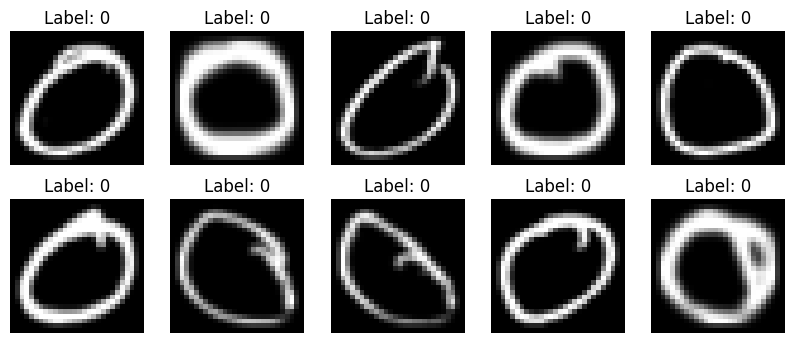

In [6]:
# Visualize some images
plt.figure(figsize=(10, 4))
for i in range(10):
  plt.subplot(2, 5, i + 1)
  plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
  plt.title(f"Label: {np.argmax(y_train[i])}")
  plt.axis("off")
plt.show()

# Task 2: Building the FCN Model

In [7]:
num_classes = 10
input_shape = (28, 28, 1)
model = keras.Sequential(
  [
    keras.layers.Input(shape=input_shape),
    keras.layers.Flatten(), # Flatten the 28x28 image to a 784-dimensional vector
    keras.layers.Dense(64, activation="sigmoid"),
    keras.layers.Dense(128, activation="sigmoid"),
    keras.layers.Dense(256, activation="sigmoid"),
    keras.layers.Dense(num_classes, activation="softmax"),
  ]
)

# Task 3: Compiling the Model

In [8]:
model.compile(
optimizer="adam",
loss="categorical_crossentropy", # Loss function for multi-class classification
metrics=["accuracy"] # Track accuracy during training
)

# Task 4: Training the Model

In [9]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="best_model.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        verbose=1
    )
]

history = model.fit(
    x_train,
    y_train,
    batch_size=128,
    epochs=20,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
104/107 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2735 - loss: 2.0323
Epoch 1: val_loss improved from None to 7.82719, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.4631 - loss: 1.6726 - val_accuracy: 0.0000e+00 - val_loss: 7.8272
Epoch 2/20
102/107 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7907 - loss: 0.6781
Epoch 2: val_loss did not improve from 7.82719
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8160 - loss: 0.5450 - val_accuracy: 8.8158e-04 - val_loss: 9.5850
Epoch 3/20
101/107 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8710 - loss: 0.3354
Epoch 3: val_loss did not improve from 7.82719
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8806 - loss: 0.3232 - val_accuracy: 8.8158e-04 - val_loss: 10.4086
Epoch 4/20
 97/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9173 - loss: 0.2518
Epoch 4: val_loss did not improve from 7.82719
107/107 ━━━━━━

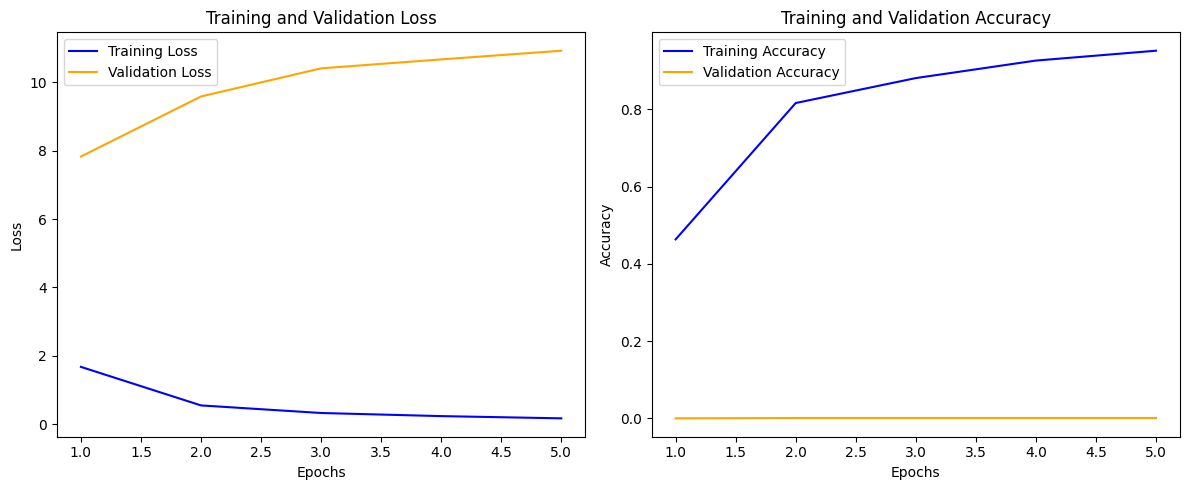

In [10]:
# plot training and validation loss and accuracy
train_loss = history.history['loss']
val_loss   = history.history['val_loss']
train_acc  = history.history['accuracy']
val_acc    = history.history['val_accuracy']

plt.figure(figsize=(12, 5))

# loss plot
plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_loss) + 1), train_loss, label='Training Loss',   color='blue')
plt.plot(range(1, len(val_loss)   + 1), val_loss,   label='Validation Loss', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

# accuracy plot
plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_acc) + 1), train_acc, label='Training Accuracy',   color='blue')
plt.plot(range(1, len(val_acc)   + 1), val_acc,   label='Validation Accuracy', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Task 5: Evaluating the Model

In [11]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

94/94 - 0s - 2ms/step - accuracy: 0.7607 - loss: 2.3142
Test Loss:     2.3142
Test Accuracy: 0.7607


# Task 6: Saving and Evaluating the Model

In [13]:
# save
model.save("/content/drive/MyDrive/AI and Machine Learning - 6th Sem/Week 4/devnagari_fcn_model.h5")
print("Model saved to devnagari_fcn_model.h5")

Model saved to devnagari_fcn_model.h5


In [14]:
# load
loaded_model = tf.keras.models.load_model("/content/drive/MyDrive/AI and Machine Learning - 6th Sem/Week 4/devnagari_fcn_model.h5")
print("Model loaded successfully")

Model loaded successfully


In [15]:
# re-evaluate loaded model
loaded_loss, loaded_acc = loaded_model.evaluate(x_test, y_test, verbose=2)
print(f"Loaded Model Test Accuracy: {loaded_acc:.4f}")

94/94 - 1s - 6ms/step - accuracy: 0.7607 - loss: 2.3142
Loaded Model Test Accuracy: 0.7607


# Task 7: Predictions

In [16]:
# make predictions
predictions      = loaded_model.predict(x_test)
predicted_labels = np.argmax(predictions, axis=1)
true_labels      = np.argmax(y_test, axis=1)

# print first 5 predictions vs true labels
for i in range(5):
    print(f"Image {i+1} — Predicted: {predicted_labels[i]}, True: {true_labels[i]}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Image 1 — Predicted: 0, True: 0
Image 2 — Predicted: 0, True: 0
Image 3 — Predicted: 7, True: 0
Image 4 — Predicted: 0, True: 0
Image 5 — Predicted: 0, True: 0


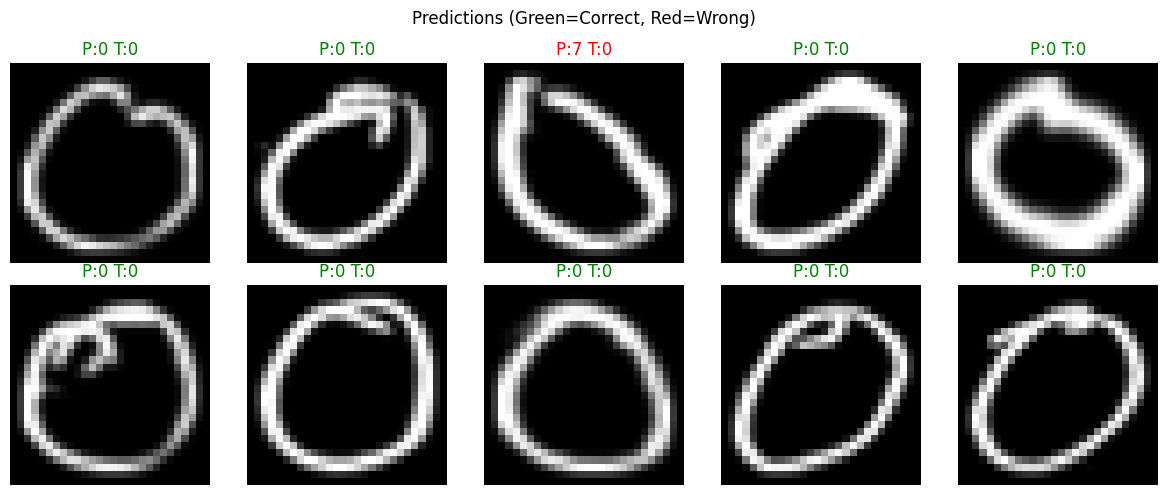

In [17]:
# visualize 10 predictions including misclassified ones
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    color = 'green' if predicted_labels[i] == true_labels[i] else 'red'
    plt.title(f"P:{predicted_labels[i]} T:{true_labels[i]}", color=color)
    plt.axis("off")
plt.suptitle("Predictions (Green=Correct, Red=Wrong)")
plt.tight_layout()
plt.show()

In [18]:
# overall final accuracy
final_acc = np.mean(predicted_labels == true_labels)
print(f"Final Prediction Accuracy: {final_acc:.4f}")

Final Prediction Accuracy: 0.7607
